# Data exploration

## Setup

In this notebook we will take the mendeley dataset from “Steam Games Dataset: Player count history, Price history and data about games”, Wannigamage, Barlow, Lakshika & Kasmarik (UNSW Canberra), 2020. DOI 10.17632/ycy3sy3vj2.1, CC BY 4.0. https://data.mendeley.com/datasets/ycy3sy3vj2/1, and process it into a form that is useful for our model. Starting with two input features for simplicity:
- A number indicating the start of a time series (e.g. 1st of Jan is denoted 0)
- The average player count per day over 90 consecutive days.

Let's load some sample data and see how we can do this.

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import sklearn
from pathlib import Path
from copy import deepcopy

print(os.getcwd())

/Users/sujai/Documents/player_forecasting/notebooks


## Viewing graphs of daily player count over time

There are some null playercount values so we choose to drop these entirely.

In [ ]:
game_id = 20540
raw_player_counts = pd.read_csv("../data/mendeley/PlayerCountHistoryPart1/"+str(game_id)+".csv")
player_counts = raw_player_counts.dropna(subset=["Playercount"])

We notice that this gives player counts every five minutes. This level of granularity isn't necessary for our model so we'd like to convert this into an average daily playercount. To do this we have to group columns by day and then take the mean.

In [ ]:
player_counts["Time"] = player_counts["Time"].str[:10]

# groupby creates a lazy object - not a dataframe. Must apply mean() aggregation onto it to get a dataframe.
# set as_index to False to prevent "Time" becoming an index
avg_players = player_counts.groupby("Time", as_index=False).mean()
avg_players.head()

,Time,Playercount
0,2017-12-14,50.0
1,2017-12-14,48.0
2,2017-12-14,48.0
3,2017-12-14,51.0
4,2017-12-14,46.0


Let's try to plot this data now. For this, having the time as a datetime object is better than a string so first convert.

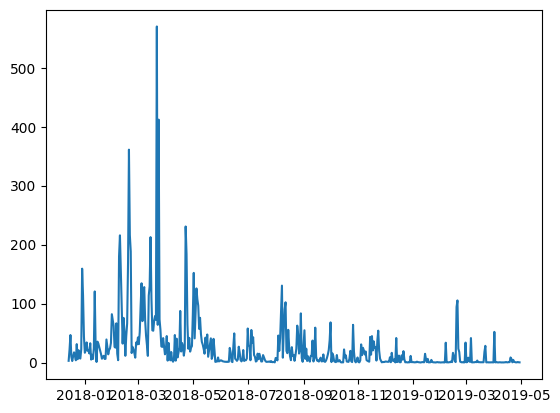

In [22]:
avg_players["Time"] = pd.to_datetime(avg_players["Time"])
window_size = 500
plt.plot(avg_players["Time"].iloc[:window_size], avg_players["Playercount"][:window_size])
plt.show()

In [23]:
# the span determines roughly how far back the exponential moving average looks 
# - for larger values it takes into account values farther in the past
ema = avg_players["Playercount"].ewm(span=14).mean()
# also check the standard moving average for comparison
roa = avg_players["Playercount"].rolling(window=8).mean()

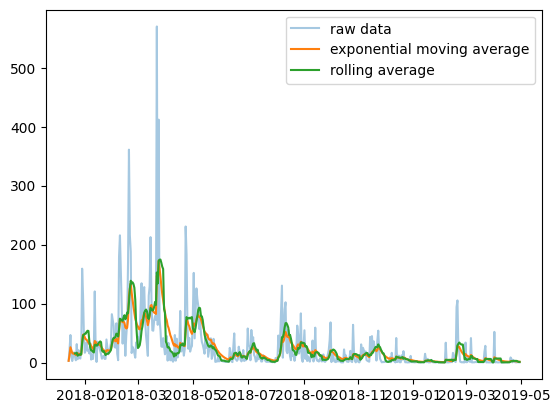

In [24]:
plt.plot(avg_players["Time"].iloc[:window_size], avg_players["Playercount"][:window_size], label='raw data', alpha=0.4)
plt.plot(avg_players["Time"].iloc[:window_size], ema.iloc[:window_size], label='exponential moving average')
plt.plot(avg_players["Time"].iloc[:window_size], roa.iloc[:window_size], label='rolling average')
plt.legend()
plt.show()

## Data processing / cleaning

First, we want to combine the 'Part 1' and 'Part 2' datasets into one dataset with daily values, so the output will be a folder with one csv file per game and daily average playercounts.

In [3]:
def to_daily_avg(playercounts: pd.DataFrame) -> pd.DataFrame:
    """Takes playercount data over time and returns daily average players.

    Args:
        playercounts: A dataframe containing times and corresponding playercounts.

    Returns:
        daily_avg: A dataframe containing daily averaged playercounts.
    
    """

    # First convert times to datetime objects
    playercounts["Time"] = pd.to_datetime(playercounts["Time"])

    # Groupby and take the mean of player counts
    playercounts["Time"] = playercounts["Time"].dt.normalize()
    avg_daily = playercounts.groupby("Time", as_index=False).mean()

    return avg_daily

Now we process the playercounts into averages and save them as csv files. Also we keep track of all the game_ids in a list.

In [ ]:
input_dir = Path("../data/mendeley/combined_playercounts")
output_dir = Path("../data/avg_daily")

# create directory if it doesn't exist, parents ensures parent folders are also created if they don't exist
# exist_ok=True means if the folders are already there do nothing.
output_dir.mkdir(parents=True, exist_ok=True)

# keep note of game_ids, useful for splitting the data later
game_ids = []

# glob is a lazy generator that searches the directory and gives path objects to any file that matches the pattern
for file in input_dir.glob("*.csv"):
    # put the data in a dataframe
    playercounts = pd.read_csv(file)
    averaged = to_daily_avg(playercounts)

    # index false prevents the output csv having an index column
    # file stem keeps only the part of the filename that is not the file extension
    averaged.to_csv(output_dir / f"{file.stem}_daily.csv", index=False)
    game_ids.append(file.stem)